<a href="https://colab.research.google.com/github/Uzema/dsp-seminars/blob/nikolaev_lab6/seminars/6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическое занятие №6: Синтез цифровых фильтров (КИХ и БИХ)

## Часть 1. Синтез КИХ-фильтров методом окон

### Задание 1.1. Проектирование ФНЧ с разными окнами
Спроектируйте КИХ-ФНЧ с частотой среза 200 Гц (частота дискретизации 1000 Гц), длина фильтра 51 отсчёт. Используйте окна:
- прямоугольное,
- Ханна,
- Хемминга,
- Блэкмана.

Постройте на одном графике АЧХ (в дБ) всех четырёх фильтров. Сравните:
- крутизну среза,
- уровень пульсаций в полосе пропускания и заграждения,
- ширину переходной полосы.


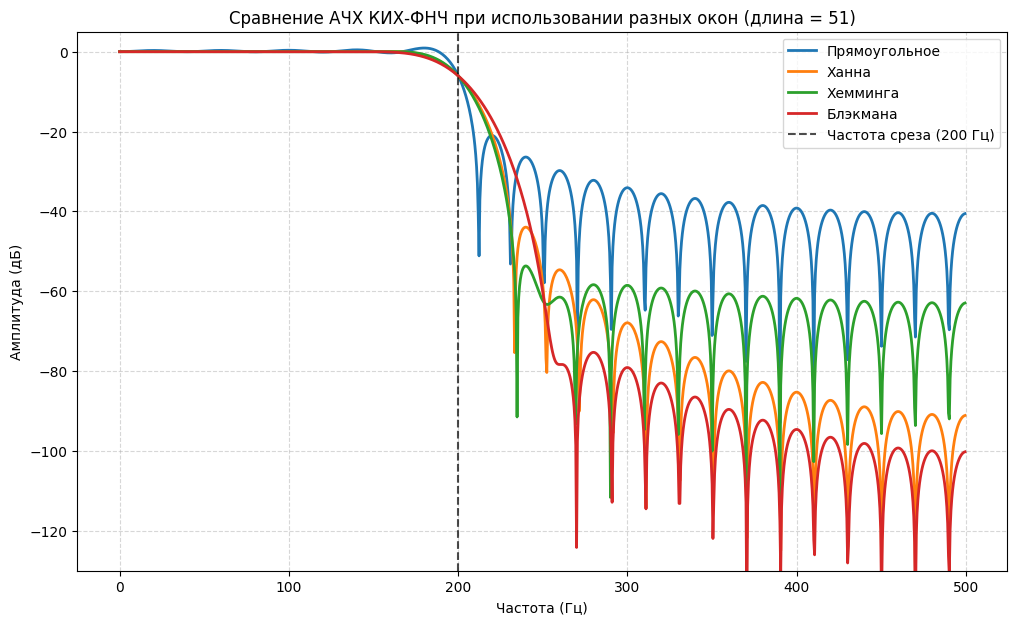

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

fs = 1000
cutoff = 200
numtaps = 51

windows = {
    'Прямоугольное': 'boxcar',
    'Ханна': 'hann',
    'Хемминга': 'hamming',
    'Блэкмана': 'blackman'
}

plt.figure(figsize=(12, 7))

for name, win_type in windows.items():
    b = signal.firwin(numtaps, cutoff, window=win_type, fs=fs)
    w, h = signal.freqz(b, a=1, worN=1024, fs=fs)
    mag_dB = 20 * np.log10(np.abs(h) + 1e-12)
    plt.plot(w, mag_dB, label=name, linewidth=2)

plt.title(f'Сравнение АЧХ КИХ-ФНЧ при использовании разных окон (длина = {numtaps})')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.axvline(cutoff, color='k', linestyle='--', alpha=0.7, label=f'Частота среза ({cutoff} Гц)')
plt.ylim(-130, 5)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(loc='upper right')
plt.show()

**Вопросы:** Какое окно обеспечивает наилучшее подавление в полосе заграждения? Какое – самую крутую переходную полосу? Как это связано с формой окна?

- Наилучшее подавление обеспечивает окно Блэкмана.
- Самую крутую переходную полосу дает прямоугольное окно (boxcar). Оно быстрее всех падает от полосы пропускания к полосе заграждения.
- Чем плавнее функция во временной области, тем меньше побочных лепестков она порождает в частотной области.

### Задание 1.2. Влияние длины фильтра
Для окна Хемминга спроектируйте ФНЧ с fc=200 Гц, fs=1000 Гц, с длинами 21, 51, 101. Постройте АЧХ на одном графике.


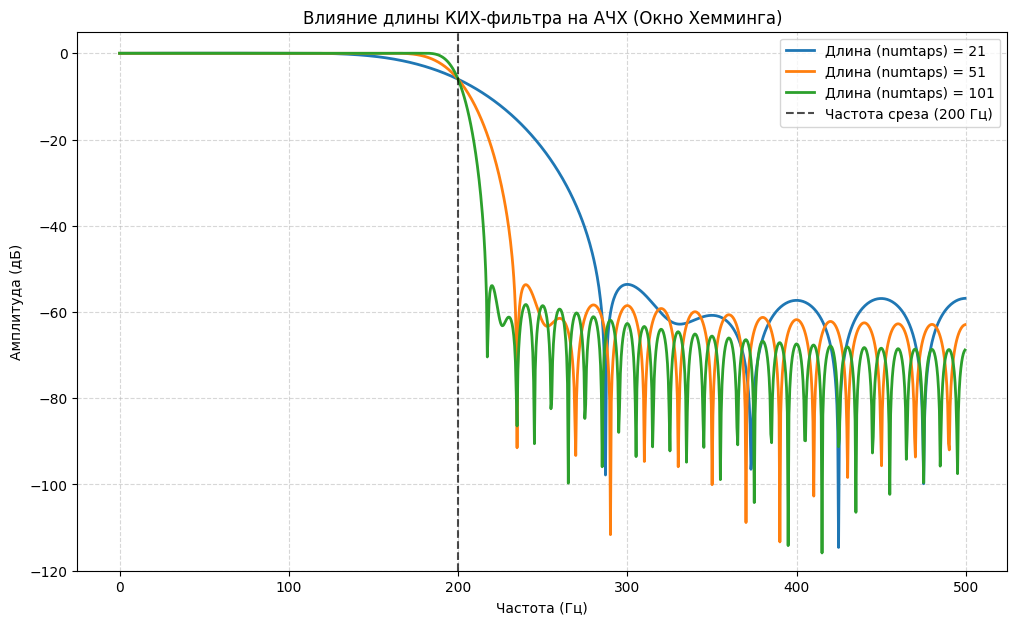

In [7]:
fs = 1000
cutoff = 200
lengths = [21, 51, 101]

plt.figure(figsize=(12, 7))

for numtaps in lengths:
    b = signal.firwin(numtaps, cutoff, window='hamming', fs=fs)
    w, h = signal.freqz(b, a=1, worN=1024, fs=fs)
    mag_dB = 20 * np.log10(np.abs(h) + 1e-12)
    plt.plot(w, mag_dB, label=f'Длина (numtaps) = {numtaps}', linewidth=2)

plt.title('Влияние длины КИХ-фильтра на АЧХ (Окно Хемминга)')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.axvline(cutoff, color='k', linestyle='--', alpha=0.7, label=f'Частота среза ({cutoff} Гц)')
plt.ylim(-120, 5)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.show()

**Вопрос:** Как увеличение длины влияет на крутизну среза и на уровень боковых лепестков?

Увеличение длины приводит к увеличению крутизны среза, а максимальный уровень боковых лепестков не меняется, а их плотность увеличивается.


### Задание 1.3. Синтез ФВЧ и полосового фильтра методом окон
Используя тот же оконный метод, спроектируйте:
- ФВЧ с fc=200 Гц (длина 51, окно Хемминга);
- полосовой фильтр с полосой пропускания 200–300 Гц (длина 51, окно Хемминга).

Постройте АЧХ обоих фильтров.


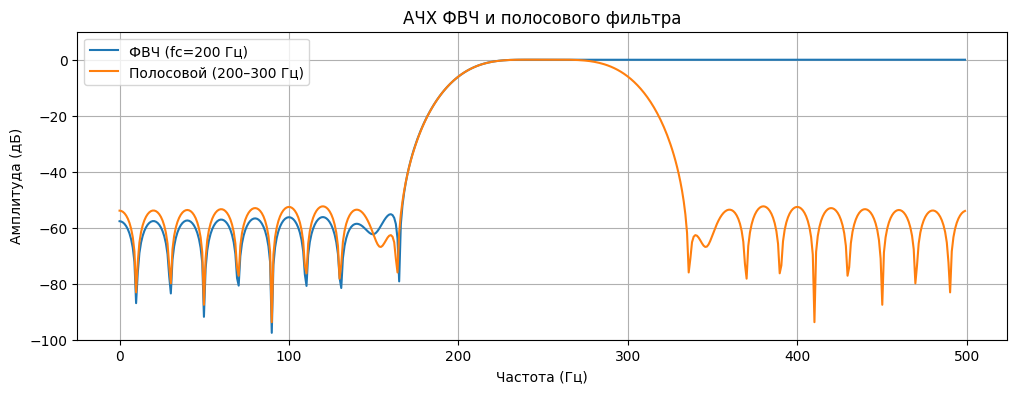

In [10]:
b_high = signal.firwin(51, 200, pass_zero=False, window='hamming', fs=fs)
b_band = signal.firwin(51, [200, 300], pass_zero=False, window='hamming', fs=fs)

w_h, h_high = signal.freqz(b_high, fs=fs)
w_b, h_band = signal.freqz(b_band, fs=fs)

plt.figure(figsize=(12, 4))
plt.plot(w_h, 20 * np.log10(np.abs(h_high) + 1e-12), label='ФВЧ (fc=200 Гц)')
plt.plot(w_b, 20 * np.log10(np.abs(h_band) + 1e-12), label='Полосовой (200–300 Гц)')
plt.title('АЧХ ФВЧ и полосового фильтра')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.grid(True)
plt.legend()
plt.ylim(-100, 10)
plt.show()

Подайте на спроектированные фильтры сигнал: сумма синусоид 100, 250 и 350 Гц (амплитуды 1, 0.8, 0.6). Постройте спектры до и после фильтрации (в логарифмическом масштабе).

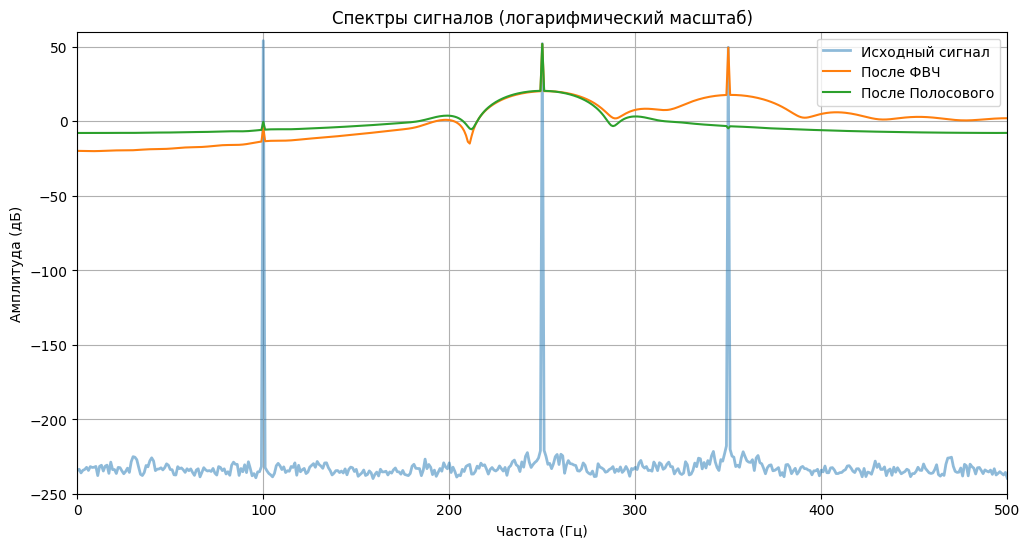

In [14]:
t = np.linspace(0, 1, fs, endpoint=False)
x = 1 * np.sin(2 * np.pi * 100 * t) + 0.8 * np.sin(2 * np.pi * 250 * t) + 0.6 * np.sin(2 * np.pi * 350 * t)

y_high = signal.lfilter(b_high, [1], x)
y_band = signal.lfilter(b_band, [1], x)

freqs = np.fft.rfftfreq(len(x), 1/fs)
X_mag = 20 * np.log10(np.abs(np.fft.rfft(x)) + 1e-12)
Y_high_mag = 20 * np.log10(np.abs(np.fft.rfft(y_high)) + 1e-12)
Y_band_mag = 20 * np.log10(np.abs(np.fft.rfft(y_band)) + 1e-12)

plt.figure(figsize=(12, 6))
plt.plot(freqs, X_mag, label='Исходный сигнал', alpha=0.5, linewidth=2)
plt.plot(freqs, Y_high_mag, label='После ФВЧ')
plt.plot(freqs, Y_band_mag, label='После Полосового')
plt.title('Спектры сигналов (логарифмический масштаб)')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.grid(True)
plt.legend()
plt.xlim(0, 500)
plt.ylim(-250, 60)
plt.show()

**Вопрос:** Объясните полученные результаты.

ФВЧ подвил низкочастотную (100 гц) составляющую и пропустил компоненты 250 и 350 гц без изменений, сохраняя свои исходные амплитуды. На выходе полосового фильтра в спектре остается только центральная синусоида 250 гц, которая попадает в полосу пропускания 200-300 гц. Боковые частоты 100 гц и 350 гц подавляются окном Хемминга.

## Часть 2. Равноволновой синтез КИХ-фильтров (Паркса–МакКлеллана)

### Задание 2.1. Проектирование оптимального ФНЧ
Используя `signal.remez`, спроектируйте ФНЧ с параметрами:
- частота дискретизации 1000 Гц,
- полоса пропускания 0–150 Гц,
- полоса заграждения 250–500 Гц,
- длина фильтра 21.

Постройте АЧХ (в линейном и логарифмическом масштабах) и сравните её с АЧХ КИХ-фильтра, полученного методом окон (окно Хемминга, та же длина, fc=200 Гц).

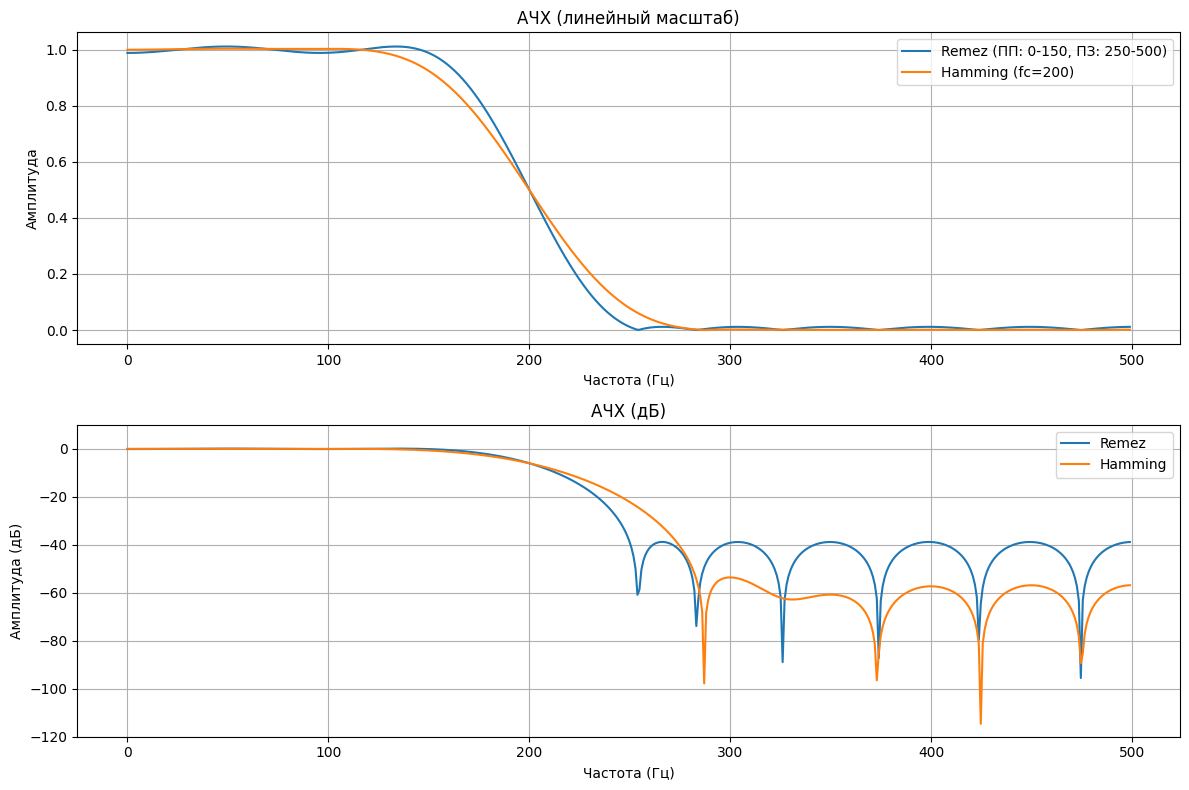

In [17]:
fs = 1000
numtaps = 21
bands_remez = [0, 150, 250, 500]
desired_remez = [1, 0]
b_remez = signal.remez(numtaps, bands_remez, desired_remez, fs=fs)
b_hamm = signal.firwin(numtaps, 200, window='hamming', fs=fs)

w_r, h_r = signal.freqz(b_remez, fs=fs)
w_h, h_h = signal.freqz(b_hamm, fs=fs)

plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(w_r, np.abs(h_r), label='Remez (ПП: 0-150, ПЗ: 250-500)')
plt.plot(w_h, np.abs(h_h), label='Hamming (fc=200)')
plt.title('АЧХ (линейный масштаб)')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(w_r, 20 * np.log10(np.abs(h_r) + 1e-12), label='Remez')
plt.plot(w_h, 20 * np.log10(np.abs(h_h) + 1e-12), label='Hamming')
plt.title('АЧХ (дБ)')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.ylim(-120, 10)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


**Вопросы:** Какой фильтр имеет более крутой срез? Каковы пульсации в полосе пропускания?

 Фильтр remez дает более крутой срез и значительно более узкую переходную полосу. Его пульсации более равномерные по сравнению с фильтром Хемминга.

### Задание 2.2. Зависимость от ширины переходной полосы

Поменяйте верхнюю частоту полосы пропускания и нижнюю частоту полосы заграждения так, чтобы их среднее оставалось равным 200 Гц. Постройте АЧХ получившегося фильтра. Подберите ширину переходной области (разности нижней частоты полосы заграждения и верхней частоты полосы пропускания) так, чтобы уровень подавления в полосе заграждения у равноволнового фильтра совпал с оконным фильтром Хемминга.


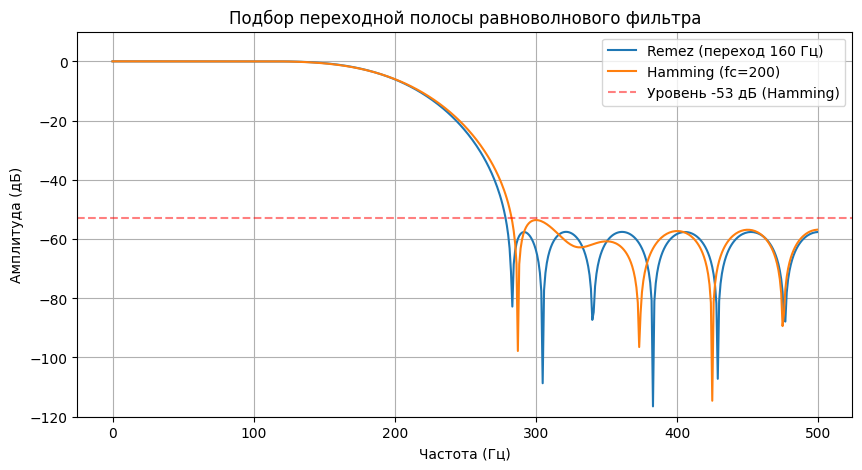

In [20]:
W = 160
f_pass = 200 - W / 2
f_stop = 200 + W / 2

b_remez_wide = signal.remez(numtaps, [0, f_pass, f_stop, 500], [1, 0], fs=fs)
w_rw, h_rw = signal.freqz(b_remez_wide, fs=fs)

plt.figure(figsize=(10, 5))
plt.plot(w_rw, 20 * np.log10(np.abs(h_rw) + 1e-12), label=f'Remez (переход {W} Гц)')
plt.plot(w_h, 20 * np.log10(np.abs(h_h) + 1e-12), label='Hamming (fc=200)')
plt.axhline(-53, color='r', linestyle='--', alpha=0.5, label='Уровень -53 дБ (Hamming)')
plt.title('Подбор переходной полосы равноволнового фильтра')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.ylim(-120, 10)
plt.grid(True)
plt.legend()
plt.show()

**Вопрос:** При какой ширине переходной области уровень подавления в полосе заграждения у равноволнового фильтра совпал с оконным фильтром Хемминга?

При ширине переходной полосы 160 Гц минимальное затухание фильтра remez в полосе заграждения сравнивается с уровнем боковых лепестков окна Хемминга.

### Задание 2.3. Управление весами
Для фильтра из задачи 2.1 измените весовые коэффициенты: задайте `weight=[1, 10]` (увеличить вес для полосы заграждения). Постройте новую АЧХ и сравните с предыдущей.


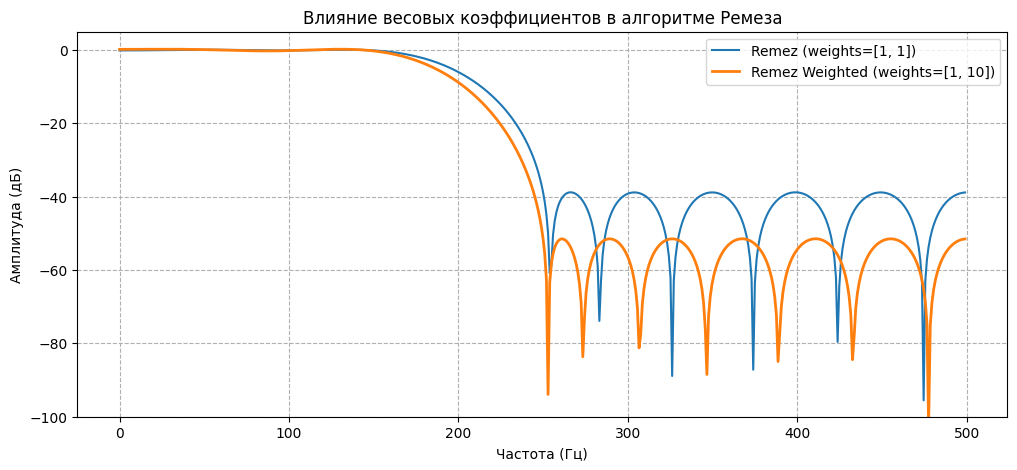

In [21]:
b_remez_weighted = signal.remez(numtaps, bands_remez, desired_remez, weight=[1, 10], fs=fs)
w_rw, h_rw = signal.freqz(b_remez_weighted, fs=fs)

plt.figure(figsize=(12, 5))
plt.plot(w_r, 20 * np.log10(np.abs(h_r) + 1e-12), label='Remez (weights=[1, 1])')
plt.plot(w_rw, 20 * np.log10(np.abs(h_rw) + 1e-12), label='Remez Weighted (weights=[1, 10])', linewidth=2)
plt.title('Влияние весовых коэффициентов в алгоритме Ремеза')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.ylim(-100, 5)
plt.grid(True, which='both', linestyle='--')
plt.legend()
plt.show()

**Вопрос:** Как изменилось подавление в полосе заграждения и пульсации в полосе пропускания?

Увеличение веса полосы заграждения в 10 раз привело к значительному увеличению затухания в ней (уровень подавления опустился примерно на 15–20 дБ ниже). Пульсации в полосе пропускания заметно возросли.

### Задание 2.4. Сравнение КИХ-фильтров на реальном сигнале
Сгенерируйте сигнал: смесь синусоид 50 Гц, 120 Гц, 220 Гц (амплитуды 1, 0.7, 0.3) + белый шум (дисперсия 0.1), fs=1000 Гц. Пропустите этот сигнал через:
- КИХ-ФНЧ спроектированный методом окон (окно Хемминга, длина 51, fc=150 Гц);
- КИХ-ФНЧ спроектированный методом `remez` (длина 51, полоса пропускания 0–100 Гц, полоса заграждения 200–500 Гц).

Постройте спектры исходного и отфильтрованных сигналов в линейном и логарифмическом масштабе.


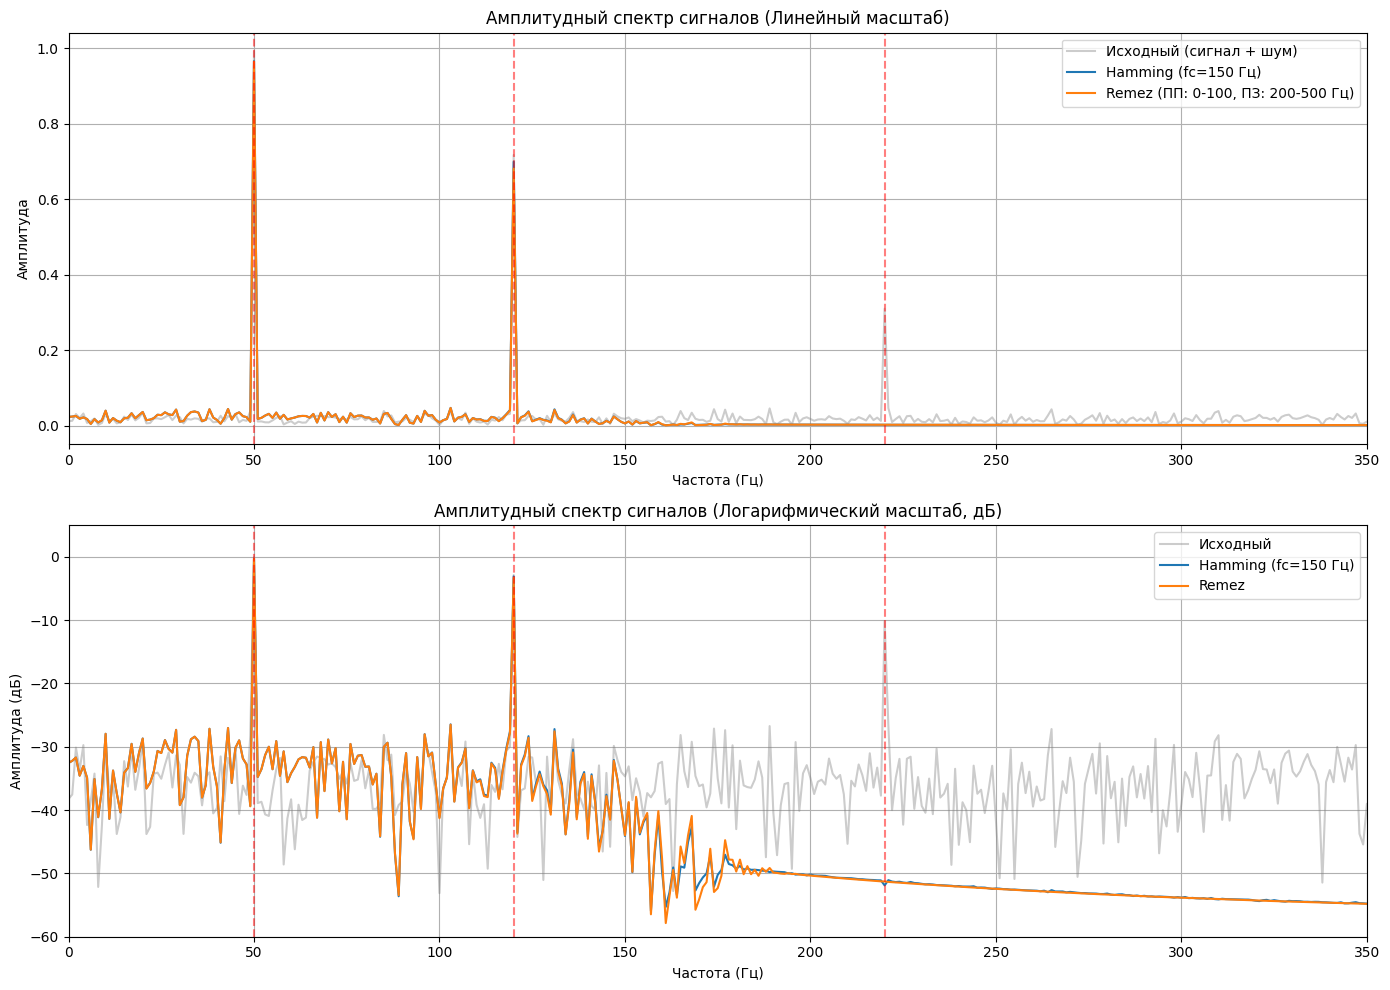

In [25]:
t = np.linspace(0, 1, fs, endpoint=False)

x_clean = 1.0 * np.sin(2 * np.pi * 50 * t) + \
          0.7 * np.sin(2 * np.pi * 120 * t) + \
          0.3 * np.sin(2 * np.pi * 220 * t)

np.random.seed(42)
x = x_clean + np.sqrt(0.1) * np.random.randn(len(t))

b_hamm = signal.firwin(51, 150, window='hamming', fs=fs)
b_remez = signal.remez(51, [0, 100, 200, 500], [1, 0], fs=fs)

y_hamm = signal.lfilter(b_hamm, [1], x)
y_remez = signal.lfilter(b_remez, [1], x)

freqs = np.fft.rfftfreq(len(x), 1/fs)
norm = len(x) / 2

X_mag = np.abs(np.fft.rfft(x)) / norm
Y_h_mag = np.abs(np.fft.rfft(y_hamm)) / norm
Y_r_mag = np.abs(np.fft.rfft(y_remez)) / norm

plt.figure(figsize=(14, 10))
target_freqs = [50, 120, 220]
plt.subplot(2, 1, 1)
plt.plot(freqs, X_mag, label='Исходный (сигнал + шум)', alpha=0.4, color='gray')
plt.plot(freqs, Y_h_mag, label='Hamming (fc=150 Гц)', color='tab:blue', linewidth=1.5)
plt.plot(freqs, Y_r_mag, label='Remez (ПП: 0-100, ПЗ: 200-500 Гц)', color='tab:orange', linewidth=1.5)
for f in target_freqs:
    plt.axvline(f, color='red', linestyle='--', alpha=0.5)
plt.title('Амплитудный спектр сигналов (Линейный масштаб)')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.xlim(0, 350)
plt.grid(True)
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(freqs, 20 * np.log10(X_mag + 1e-12), label='Исходный', alpha=0.4, color='gray')
plt.plot(freqs, 20 * np.log10(Y_h_mag + 1e-12), label='Hamming (fc=150 Гц)', color='tab:blue')
plt.plot(freqs, 20 * np.log10(Y_r_mag + 1e-12), label='Remez', color='tab:orange')
for f in target_freqs:
    plt.axvline(f, color='red', linestyle='--', alpha=0.5)
plt.title('Амплитудный спектр сигналов (Логарифмический масштаб, дБ)')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.xlim(0, 350)
plt.ylim(-60, 5)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

**Вопросы:** Какой фильтр лучше подавил 220 Гц и шум? Какой лучше сохранил 120 Гц? На сколько отличаются амплитуды 120 Гц сигнала от исходных для каждого из фильтров?


Фильтр remez значительно лучше подавил частоту 220 Гц и высокочастотный шум, так как у него полоса заграждения начинается строго с 200 Гц и обеспечивает более высокую крутизну спада.

Компоненту 120 Гц лучше сохранил фильтр hamming.

Амплитуда 120 Гц у фильтра hamming практически не изменилась, в то время как у Remez она просела.

## Часть 3. Синтез БИХ-фильтров

### Задание 3.1. Баттерворт, Чебышев, эллиптический – сравнение АЧХ
Спроектируйте ФНЧ с частотой среза 200 Гц (fs=1000 Гц) следующих типов (порядок 4):
- Баттерворт (`butter`);
- Чебышев I с пульсациями 1 дБ (`cheby1`);
- Чебышев II с затуханием 40 дБ в полосе заграждения (`cheby2`);
- Эллиптический с пульсациями 1 дБ и затуханием 40 дБ (`ellip`).

Постройте АЧХ всех фильтров на одном графике (в дБ). Сравните:
- крутизну среза,
- пульсации в полосе пропускания и заграждения.

Постройте и сравните фазовые характеристики (ФЧХ) и групповые задержки.


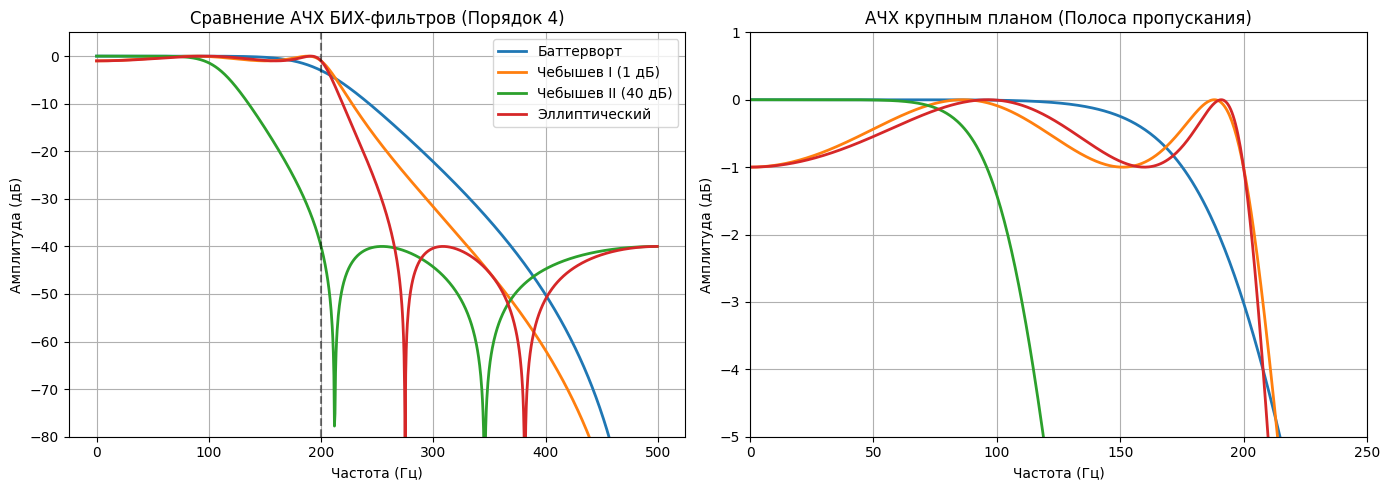

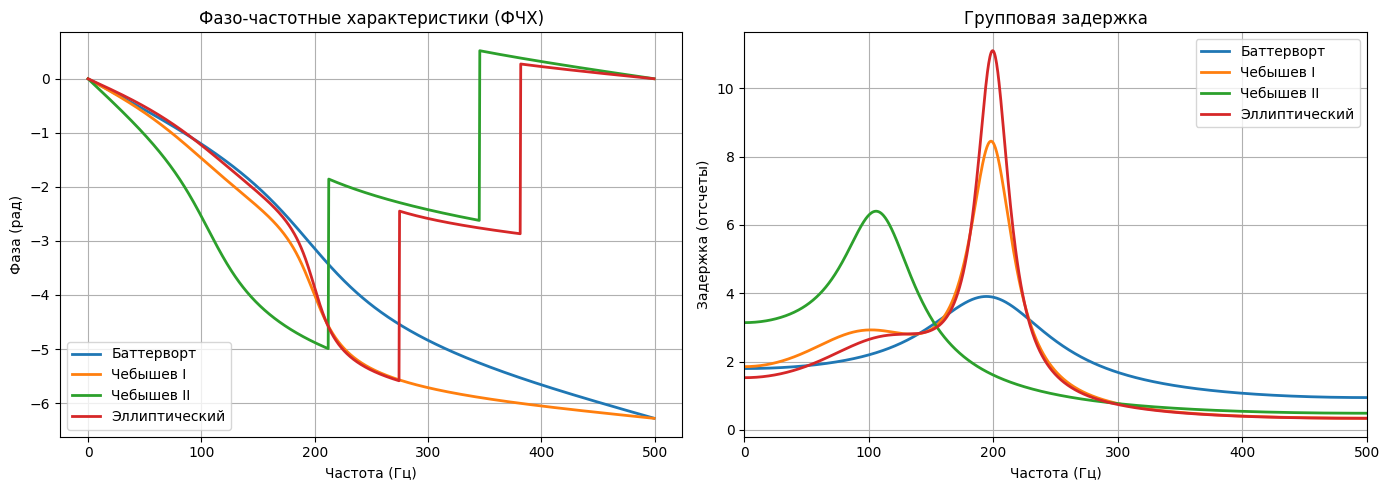

In [18]:
fs = 1000
cutoff = 200
N = 4
rp = 1
rs = 40

b_butter, a_butter = signal.butter(N, cutoff, btype='low', fs=fs)
b_cheby1, a_cheby1 = signal.cheby1(N, rp, cutoff, btype='low', fs=fs)
b_cheby2, a_cheby2 = signal.cheby2(N, rs, cutoff, btype='low', fs=fs)
b_ellip, a_ellip = signal.ellip(N, rp, rs, cutoff, btype='low', fs=fs)

w_b, h_b = signal.freqz(b_butter, a_butter, worN=1024, fs=fs)
w_c1, h_c1 = signal.freqz(b_cheby1, a_cheby1, worN=1024, fs=fs)
w_c2, h_c2 = signal.freqz(b_cheby2, a_cheby2, worN=1024, fs=fs)
w_e, h_e = signal.freqz(b_ellip, a_ellip, worN=1024, fs=fs)

gd_b = signal.group_delay((b_butter, a_butter), w=w_b, fs=fs)[1]
gd_c1 = signal.group_delay((b_cheby1, a_cheby1), w=w_c1, fs=fs)[1]
gd_c2 = signal.group_delay((b_cheby2, a_cheby2), w=w_c2, fs=fs)[1]
gd_e = signal.group_delay((b_ellip, a_ellip), w=w_e, fs=fs)[1]

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(w_b, 20*np.log10(np.abs(h_b)+1e-12), label='Баттерворт', linewidth=2)
plt.plot(w_c1, 20*np.log10(np.abs(h_c1)+1e-12), label='Чебышев I (1 дБ)', linewidth=2)
plt.plot(w_c2, 20*np.log10(np.abs(h_c2)+1e-12), label='Чебышев II (40 дБ)', linewidth=2)
plt.plot(w_e, 20*np.log10(np.abs(h_e)+1e-12), label='Эллиптический', linewidth=2)
plt.title('Сравнение АЧХ БИХ-фильтров (Порядок 4)')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.axvline(cutoff, color='k', linestyle='--', alpha=0.5)
plt.ylim(-80, 5)
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(w_b, 20*np.log10(np.abs(h_b)+1e-12), linewidth=2)
plt.plot(w_c1, 20*np.log10(np.abs(h_c1)+1e-12), linewidth=2)
plt.plot(w_c2, 20*np.log10(np.abs(h_c2)+1e-12), linewidth=2)
plt.plot(w_e, 20*np.log10(np.abs(h_e)+1e-12), linewidth=2)
plt.title('АЧХ крупным планом (Полоса пропускания)')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.xlim(0, 250)
plt.ylim(-5, 1)
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(w_b, np.unwrap(np.angle(h_b)), label='Баттерворт', linewidth=2)
plt.plot(w_c1, np.unwrap(np.angle(h_c1)), label='Чебышев I', linewidth=2)
plt.plot(w_c2, np.unwrap(np.angle(h_c2)), label='Чебышев II', linewidth=2)
plt.plot(w_e, np.unwrap(np.angle(h_e)), label='Эллиптический', linewidth=2)
plt.title('Фазо-частотные характеристики (ФЧХ)')
plt.xlabel('Частота (Гц)')
plt.ylabel('Фаза (рад)')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(w_b, gd_b, label='Баттерворт', linewidth=2)
plt.plot(w_c1, gd_c1, label='Чебышев I', linewidth=2)
plt.plot(w_c2, gd_c2, label='Чебышев II', linewidth=2)
plt.plot(w_e, gd_e, label='Эллиптический', linewidth=2)
plt.title('Групповая задержка')
plt.xlabel('Частота (Гц)')
plt.ylabel('Задержка (отсчеты)')
plt.xlim(0, 500)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

**Вопросы:** Какой фильтр даёт самый крутой спад? Какой имеет наименьшие фазовые искажения в полосе пропускания?


Ваш ответ здесь

### Задание 3.2. Влияние порядка на характеристики БИХ-фильтра
Для фильтра Баттерворта с fc=200 Гц, fs=1000 Гц возьмите порядки 2, 4, 6. Постройте АЧХ и групповую задержку.


In [ ]:
# Ваш код здесь

**Вопросы:** Как увеличение порядка влияет на крутизну среза и на групповую задержку в полосе пропускания?

Ваши ответы здесь

### Задание 3.3. Преобразование типа БИХ-фильтра (ФНЧ → ФВЧ, полосовой)
Спроектируйте Баттерворта 4-го порядка:
- ФНЧ с fc=200 Гц;
- ФВЧ с fc=200 Гц (используйте `btype='high'`);
- полосовой с полосой 200–300 Гц.

Подайте на них сигнал: сумма синусоид 100, 250, 400 Гц. Постройте спектры после фильтрации.


In [ ]:
# Ваш код здесь

**Вопрос:** Какие составляющие подавлены, а какие пропущены в каждом случае?

Ваш ответ здесь

### Задание 3.4. Применение БИХ-фильтра к зашумлённому сигналу
Сгенерируйте сигнал: синусоида 50 Гц + белый шум с дисперсией 0.2, fs=1000 Гц, длительность 1 с. Спроектируйте эллиптический ФНЧ с fc=100 Гц (порядок 6, пульсации 1 дБ, затухание 40 дБ). Примените фильтр с помощью `lfilter` и `filtfilt`. Постройте на одном графике исходный и отфильтрованные сигналы (временные области, первые 0.2 с), а также их спектры. Сравните задержку и подавление шума.


In [ ]:
# Ваш код здесь

**Вопрос:** Почему `filtfilt` даёт нулевой фазовый сдвиг?

Ваш ответ здесь

## Часть 4. Сравнение КИХ и БИХ фильтров одинакового порядка

### Задание 4.1. Сравнение характеристик
Спроектируйте:
- КИХ-ФНЧ методом окон (окно Хемминга, длина 51, fc=200 Гц);
- БИХ-ФНЧ Баттерворта 4-го порядка (fc=200 Гц).

Постройте для них на одном графике:
- отдельно АЧХ (в дБ),
- отдельно групповую задержку.


In [ ]:
# Ваш код здесь

**Вопросы:** Какой фильтр имеет более крутой срез? Какой имеет постоянную групповую задержку? Какой вносит меньшие фазовые искажения? Какой требует меньше вычислений? Попробуйте увеличить порядок фильтра Баттерворта. При каком порядке крутизна среза его АЧХ становится сравнимой с КИХ-фильтром? Растут или уменьшаются при этом фазовые искажения?


Ваши ответы здесь

### Задание 4.2. Применение к реальному сигналу
Сгенерируйте сигнал: короткий прямоугольный импульс длительностью 10 мс, а также высокочастотная синусоидальная помеха 400 Гц. Частоту дискретизации возьмите fs=10000 Гц.

Примените оба фильтра (КИХ и БИХ из предыдущего пункта). Постройте исходный и отфильтрованные сигналы.


In [ ]:
# Ваш код здесь

**Вопросы:** Какой фильтр лучше сохранил форму импульсов? Какой лучше подавил помеху?

Ваши ответы здесь